In [25]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

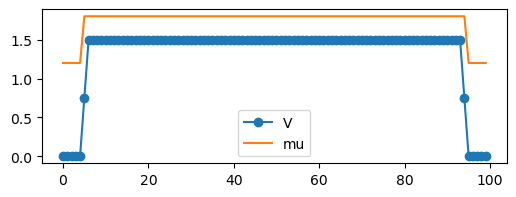

In [26]:
widthN =5
widthP =90

X, Y = widthN+widthP+widthN, 60
lattice = Lattice(X, Y)
t = 1
T=0.001

muN = 1.2 * t
muP = 1.8 * t
mu = np.ones(lattice.X) * muN
mu[widthN:widthN+widthP] = muP

U = None
V_prime = None

V0 = 1.5 * t
V = np.zeros(lattice.X)
V[widthN:widthP+widthN] = V0
V[widthN] = V0/2
V[widthN+widthP-1] = V0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, label='mu')
plt.legend()

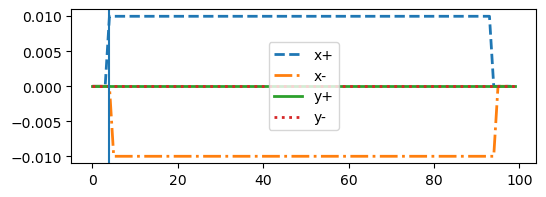

In [27]:
H = Hamiltonian(t, mu, lattice,
                U=U, V_prime=V_prime, V=V,
                F_init=[0.01, -0.01, 0.01j, -0.01j])

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(H.F0, label="F0")
if V is not None:
    plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.real(H.F_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.real(H.F_ymin), label="y-", linestyle=':', lw=2)
if V_prime is not None:
    plt.plot(np.real(H.Fuu_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.Fuu_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.Fuu_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.Fuu_ymin), label="y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(widthN-1)

In [28]:
bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=100, verbose=True, temperature=T, mixing=0.2)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.00013276687609904198
Relative error: 132766876.099042
Average old: 0j
Average: (-2.811878334341156e-18+0j)
F_xplus:
Absolute error: 0.002864788598786777
Relative error: 888758711.2362643
Average old: (0.00909090909090909+0j)
Average: (0.009072129557003405+0j)
F_xmin:
Absolute error: 0.002864788598786787
Relative error: 888758711.2362775
Average old: (-0.00909090909090909+0j)
Average: (-0.009072129557003403+0j)
F_yplus:
Absolute error: 0.0036371887637875904
Relative error: 2790107273.9640865
Average old: 0.009j
Average: (2.00509639274038e-18+0.009264527596342357j)
F_ymin:
Absolute error: 0.0036371887637875904
Relative error: 2790107273.9640865
Average old: -0.009j
Average: (2.00509639274038e-18-0.009264527596342357j)
Fuu_xplus:
Absolute error: 6.95987253361312e-18
Relative error: 6.959872533613119e-06
Average old: 0j
Average: (1.3778475068642685e-20+0j)
Fuu_xmin:
Absolute error: 6.5383662811475894e-18
Relative error: 6.5383662811475895e-06
Average old: 0j
Average: 

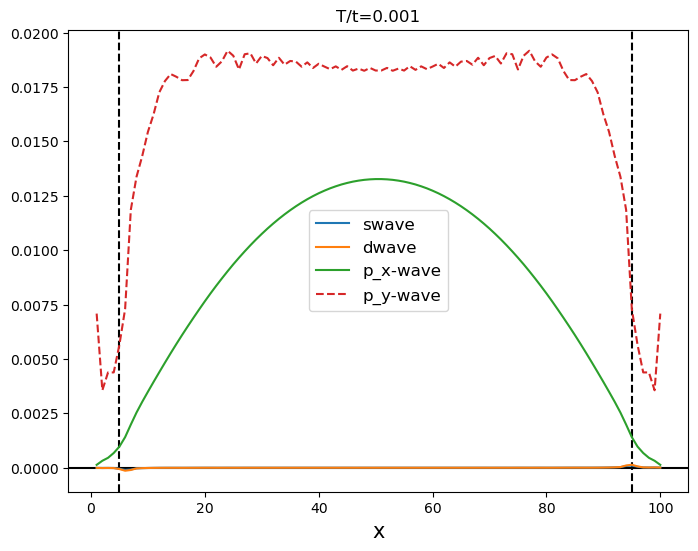

In [29]:
x = np.arange(1, widthN + widthP + widthN + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}")
axs.axhline(0, color = 'black')
axs.axvline(widthN, color='black', linestyle='--')
axs.axvline(widthN+widthP, color='black', linestyle='--')
axs.plot(x, np.real(F.swave), label="swave")

axs.plot(x, np.real(F.dwave), label="dwave")
axs.plot(x, np.real(F.px), label="p_x-wave")
axs.plot(x, np.imag(F.py), "--", label="p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.set_xlim(20, 45)
# axs.set_ylim(None, 0.3)

axs.legend(fontsize=12, loc="best")
plt.show()

In [30]:
from scripts.utils import is_hermitian

print(is_hermitian(H.build_H_k(np.pi/4)))
print(is_hermitian(H.build_H_kindep()))
print(is_hermitian(H.build_H_k0()))

True
True
True
